# Cyberbullying Detection using Machine Learning

## MCA Final Year Project

### Author: Group 1
### Department: Master of Computer Applications
### Academic Year: 2025–2026

---

**Pipeline Overview:**
1. Data Loading & EDA
2. Text Preprocessing
3. Train / Validation / Test Split (no data leakage)
4. Baseline Models (TF-IDF + LR / NB / SVM)
5. Improved Classical Models with proper threshold tuning
6. BERT-based Model (`toxic-bert`)
7. Full Model Comparison & Save

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    hamming_loss, roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Download NLTK Resources

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 3. Load Dataset

In [3]:
df = pd.read_csv("data/train.csv")

label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Dataset Shape: (159571, 8)

Missing Values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## 4. Exploratory Data Analysis

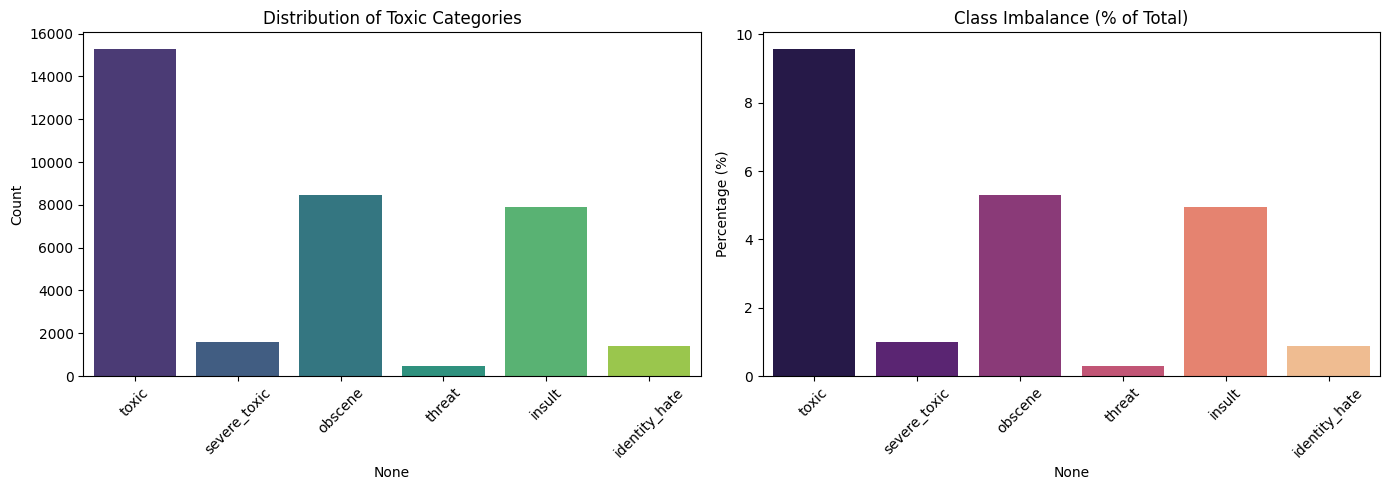


Label Counts:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

Class Imbalance (% of total):
toxic            9.58
severe_toxic     1.00
obscene          5.29
threat           0.30
insult           4.94
identity_hate    0.88
dtype: float64


In [4]:
# Label distribution
label_counts = df[label_columns].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title("Distribution of Toxic Categories")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_ylabel("Count")

# Class imbalance %
imbalance = (label_counts / len(df) * 100).round(2)
sns.barplot(x=imbalance.index, y=imbalance.values, ax=axes[1], palette='magma')
axes[1].set_title("Class Imbalance (% of Total)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

print("\nLabel Counts:")
print(label_counts)
print("\nClass Imbalance (% of total):")
print(imbalance)

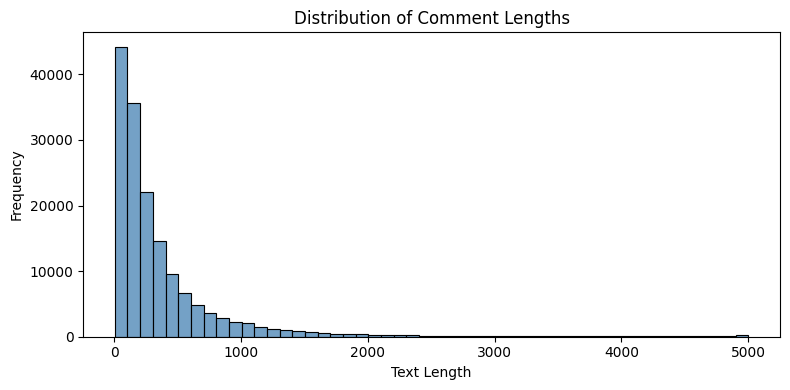


Text Length Stats:
count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: text_length, dtype: float64


In [5]:
# Comment length distribution
df['text_length'] = df['comment_text'].apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(df['text_length'], bins=50, color='steelblue')
plt.title("Distribution of Comment Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nText Length Stats:")
print(df['text_length'].describe())

## 5. Text Preprocessing

Enhanced preprocessing:
- Lowercase conversion
- URL and IP removal
- Repeated character normalization (e.g., `haaate` → `hate`)
- Punctuation removal
- Stopword removal + Lemmatization

In [6]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negations — they matter for toxicity
negations = {'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere'}
stop_words -= negations

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # remove URLs
    text = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', '', text)   # remove IPs
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)                 # normalize repeated chars
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)                   # keep only letters
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in stop_words and len(w) > 1]
    return " ".join(words)

print("Cleaning text... (this may take a few minutes)")
df['clean_text'] = df['comment_text'].apply(clean_text)
print("Done.")
df[['comment_text', 'clean_text']].head()

Cleaning text... (this may take a few minutes)
Done.


,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,aww match background colour seemingly stuck th...
2,"Hey man, I'm really not trying to edit war. It...",hey man really not trying edit war guy constan...
3,"""\nMore\nI can't make any real suggestions on ...",make real suggestion improvement wondered sect...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page


## 6. Train / Validation / Test Split

> **Important:** We use a **3-way split** (60% train, 20% validation, 20% test).
> Threshold tuning is done on the **validation set only**, so the test set
> remains completely unseen — this prevents data leakage.

In [7]:
X_all = df['clean_text']
y_all = df[label_columns]

# Step 1: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42
)

# Step 2: 75% of trainval = train (60% of total), 25% = val (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

print(f"Train   : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Val     : {X_val.shape[0]:,} samples  ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"Test    : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(df)*100:.0f}%)")

Train   : 95,742 samples  (60%)
Val     : 31,914 samples  (20%)
Test    : 31,915 samples  (20%)


## 7. TF-IDF Feature Engineering

In [8]:
# ── Baseline TF-IDF (5,000 unigrams) ───────────────────────────────
tfidf_baseline = TfidfVectorizer(max_features=5000)
X_train_b = tfidf_baseline.fit_transform(X_train)
X_val_b   = tfidf_baseline.transform(X_val)
X_test_b  = tfidf_baseline.transform(X_test)

# ── Improved TF-IDF (50,000 features, bigrams, sublinear TF) ────────
tfidf_improved = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode'
)
X_train_i = tfidf_improved.fit_transform(X_train)
X_val_i   = tfidf_improved.transform(X_val)
X_test_i  = tfidf_improved.transform(X_test)

print("Baseline TF-IDF shape  :", X_train_b.shape)
print("Improved TF-IDF shape  :", X_train_i.shape)

Baseline TF-IDF shape  : (95742, 5000)
Improved TF-IDF shape  : (95742, 50000)


## 8. Baseline Models

In [9]:
# Logistic Regression (Baseline)
log_model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
log_model.fit(X_train_b, y_train)
y_pred_log = log_model.predict(X_test_b)

print("\n===== Baseline: Logistic Regression =====")
print(classification_report(y_test, y_pred_log, target_names=label_columns, zero_division=0))
log_f1 = f1_score(y_test, y_pred_log, average='macro', zero_division=0)
print(f"Macro F1  : {log_f1:.4f}")
print(f"Subset Acc: {accuracy_score(y_test, y_pred_log):.4f}")


===== Baseline: Logistic Regression =====
               precision    recall  f1-score   support

        toxic       0.91      0.61      0.73      3056
 severe_toxic       0.60      0.26      0.36       321
      obscene       0.92      0.64      0.75      1715
       threat       0.56      0.07      0.12        74
       insult       0.82      0.52      0.64      1614
identity_hate       0.75      0.17      0.27       294

    micro avg       0.88      0.56      0.68      7074
    macro avg       0.76      0.38      0.48      7074
 weighted avg       0.87      0.56      0.67      7074
  samples avg       0.06      0.05      0.05      7074

Macro F1  : 0.4797
Subset Acc: 0.9196


In [10]:
# Naive Bayes (Baseline)
nb_model = OneVsRestClassifier(MultinomialNB())
nb_model.fit(X_train_b, y_train)
y_pred_nb = nb_model.predict(X_test_b)

print("\n===== Baseline: Naive Bayes =====")
print(classification_report(y_test, y_pred_nb, target_names=label_columns, zero_division=0))
nb_f1 = f1_score(y_test, y_pred_nb, average='macro', zero_division=0)
print(f"Macro F1  : {nb_f1:.4f}")
print(f"Subset Acc: {accuracy_score(y_test, y_pred_nb):.4f}")


===== Baseline: Naive Bayes =====
               precision    recall  f1-score   support

        toxic       0.92      0.52      0.66      3056
 severe_toxic       0.60      0.14      0.23       321
      obscene       0.91      0.53      0.67      1715
       threat       0.00      0.00      0.00        74
       insult       0.83      0.43      0.57      1614
identity_hate       0.62      0.05      0.09       294

    micro avg       0.89      0.46      0.60      7074
    macro avg       0.65      0.28      0.37      7074
 weighted avg       0.86      0.46      0.59      7074
  samples avg       0.05      0.04      0.04      7074

Macro F1  : 0.3708
Subset Acc: 0.9125


In [11]:
# Linear SVM (Baseline)
svm_model = OneVsRestClassifier(LinearSVC())
svm_model.fit(X_train_b, y_train)
y_pred_svm = svm_model.predict(X_test_b)

print("\n===== Baseline: Linear SVM =====")
print(classification_report(y_test, y_pred_svm, target_names=label_columns, zero_division=0))
svm_f1 = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)
print(f"Macro F1  : {svm_f1:.4f}")
print(f"Subset Acc: {accuracy_score(y_test, y_pred_svm):.4f}")


===== Baseline: Linear SVM =====
               precision    recall  f1-score   support

        toxic       0.87      0.67      0.76      3056
 severe_toxic       0.57      0.24      0.34       321
      obscene       0.89      0.70      0.78      1715
       threat       0.57      0.22      0.31        74
       insult       0.80      0.57      0.67      1614
identity_hate       0.70      0.28      0.40       294

    micro avg       0.85      0.61      0.71      7074
    macro avg       0.73      0.45      0.54      7074
 weighted avg       0.84      0.61      0.70      7074
  samples avg       0.06      0.05      0.06      7074

Macro F1  : 0.5429
Subset Acc: 0.9198


## 9. Improved Classical Models

Improvements applied:
- **Larger TF-IDF** (50,000 features + bigrams + sublinear TF)
- **Class weighting** (`class_weight='balanced'`) to handle imbalance
- **Threshold tuning on the validation set** ← fixes the data leakage bug
- **Calibrated SVM** for probability estimates
- **SGD Classifier** (fast, high-dimensional, good alternative to SVM)

In [12]:
# Improved Logistic Regression
log_model_imp = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', C=5.0, solver='lbfgs')
)
log_model_imp.fit(X_train_i, y_train)

print("\n===== Improved: Logistic Regression =====")
y_pred_log_imp = log_model_imp.predict(X_test_i)
print(classification_report(y_test, y_pred_log_imp, target_names=label_columns, zero_division=0))
log_f1_imp = f1_score(y_test, y_pred_log_imp, average='macro', zero_division=0)
print(f"Macro F1  : {log_f1_imp:.4f}")


===== Improved: Logistic Regression =====
               precision    recall  f1-score   support

        toxic       0.69      0.83      0.75      3056
 severe_toxic       0.30      0.76      0.43       321
      obscene       0.74      0.85      0.79      1715
       threat       0.28      0.69      0.40        74
       insult       0.61      0.82      0.70      1614
identity_hate       0.34      0.66      0.45       294

    micro avg       0.62      0.82      0.70      7074
    macro avg       0.49      0.77      0.59      7074
 weighted avg       0.65      0.82      0.72      7074
  samples avg       0.06      0.08      0.07      7074

Macro F1  : 0.5864


In [13]:
# Improved Linear SVM (calibrated for probability output)
svm_model_imp = OneVsRestClassifier(
    CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000), cv=3)
)
svm_model_imp.fit(X_train_i, y_train)

print("\n===== Improved: Calibrated SVM =====")
y_pred_svm_imp = svm_model_imp.predict(X_test_i)
print(classification_report(y_test, y_pred_svm_imp, target_names=label_columns, zero_division=0))
svm_f1_imp = f1_score(y_test, y_pred_svm_imp, average='macro', zero_division=0)
print(f"Macro F1  : {svm_f1_imp:.4f}")


===== Improved: Calibrated SVM =====
               precision    recall  f1-score   support

        toxic       0.87      0.67      0.76      3056
 severe_toxic       0.56      0.21      0.31       321
      obscene       0.88      0.69      0.77      1715
       threat       0.54      0.26      0.35        74
       insult       0.81      0.54      0.64      1614
identity_hate       0.74      0.23      0.36       294

    micro avg       0.85      0.60      0.70      7074
    macro avg       0.73      0.43      0.53      7074
 weighted avg       0.83      0.60      0.69      7074
  samples avg       0.06      0.05      0.05      7074

Macro F1  : 0.5309


In [14]:
# SGD Classifier (fast alternative, great for sparse TF-IDF)
sgd_model = OneVsRestClassifier(
    SGDClassifier(loss='modified_huber', class_weight='balanced',
                  max_iter=100, random_state=42, n_jobs=-1)
)
sgd_model.fit(X_train_i, y_train)

print("\n===== SGD Classifier =====")
y_pred_sgd = sgd_model.predict(X_test_i)
print(classification_report(y_test, y_pred_sgd, target_names=label_columns, zero_division=0))
sgd_f1 = f1_score(y_test, y_pred_sgd, average='macro', zero_division=0)
print(f"Macro F1  : {sgd_f1:.4f}")


===== SGD Classifier =====
               precision    recall  f1-score   support

        toxic       0.66      0.84      0.74      3056
 severe_toxic       0.28      0.84      0.42       321
      obscene       0.71      0.88      0.78      1715
       threat       0.29      0.61      0.39        74
       insult       0.57      0.86      0.69      1614
identity_hate       0.27      0.70      0.39       294

    micro avg       0.58      0.85      0.69      7074
    macro avg       0.46      0.79      0.57      7074
 weighted avg       0.62      0.85      0.71      7074
  samples avg       0.06      0.08      0.07      7074

Macro F1  : 0.5701


## 10. Threshold Tuning (on Validation Set — No Data Leakage)

Instead of using a fixed 0.5 decision threshold, we find the best threshold
per label on the **validation set**. This is then applied to test set predictions.

In [15]:
print("Tuning thresholds on VALIDATION SET for Logistic Regression...\n")

# Validation probabilities (used to find best thresholds)
y_proba_val = np.column_stack([
    est.predict_proba(X_val_i)[:, 1]
    for est in log_model_imp.estimators_
])

best_thresholds = []
for i, label in enumerate(label_columns):
    best_t, best_f = 0.5, 0
    for t in np.arange(0.05, 0.95, 0.025):
        preds = (y_proba_val[:, i] >= t).astype(int)
        score = f1_score(y_val.iloc[:, i], preds, zero_division=0)
        if score > best_f:
            best_f, best_t = score, t
    best_thresholds.append(best_t)
    print(f"  {label:15s} -> threshold: {best_t:.3f}  |  Val F1: {best_f:.4f}")

# Apply tuned thresholds to TEST SET (not val — no leakage)
y_proba_test = np.column_stack([
    est.predict_proba(X_test_i)[:, 1]
    for est in log_model_imp.estimators_
])
y_pred_tuned = (y_proba_test >= np.array(best_thresholds)).astype(int)

print("\n===== Threshold-Tuned Logistic Regression (Test Set) =====")
print(classification_report(y_test, y_pred_tuned, target_names=label_columns, zero_division=0))
log_f1_tuned = f1_score(y_test, y_pred_tuned, average='macro', zero_division=0)
print(f"Macro F1 (Tuned): {log_f1_tuned:.4f}")

Tuning thresholds on VALIDATION SET for Logistic Regression...

  toxic           -> threshold: 0.775  |  Val F1: 0.7761
  severe_toxic    -> threshold: 0.825  |  Val F1: 0.4598
  obscene         -> threshold: 0.675  |  Val F1: 0.8047
  threat          -> threshold: 0.875  |  Val F1: 0.4787
  insult          -> threshold: 0.800  |  Val F1: 0.7131
  identity_hate   -> threshold: 0.800  |  Val F1: 0.4876

===== Threshold-Tuned Logistic Regression (Test Set) =====
               precision    recall  f1-score   support

        toxic       0.82      0.73      0.77      3056
 severe_toxic       0.37      0.62      0.47       321
      obscene       0.80      0.82      0.81      1715
       threat       0.39      0.47      0.43        74
       insult       0.72      0.69      0.71      1614
identity_hate       0.47      0.53      0.50       294

    micro avg       0.73      0.73      0.73      7074
    macro avg       0.59      0.64      0.61      7074
 weighted avg       0.75      0.73   

## 11. BERT-Based Model: `toxic-bert`

We use [`unitary/toxic-bert`](https://huggingface.co/unitary/toxic-bert),
a BERT model fine-tuned specifically on the **Jigsaw Toxic Comment Classification** dataset.
This gives near-state-of-the-art performance without fine-tuning from scratch.

**Requirements:** `pip install transformers torch`

In [ ]:
from transformers import pipeline
import torch

print("Loading toxic-bert model...")
print(f"GPU available: {torch.cuda.is_available()}")

device = -1 
bert_classifier = pipeline(
    "text-classification",
    model="unitary/toxic-bert",
    top_k=None,
    device=device,
    truncation=True,
    max_length=512
)

print("Model loaded successfully.")

d:\Code X\ITER (SOA)\iter final year\Cyber Bullying\.zenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading toxic-bert model...
GPU available: False


In [ ]:
BERT_THRESHOLD = 0.5

def predict_bert_batch(texts, threshold=BERT_THRESHOLD):
    """Run toxic-bert on a list of texts. Returns (n_samples, 6) array."""
    results = bert_classifier(texts, batch_size=32)
    preds = []
    for result in results:
        score_dict = {item['label']: item['score'] for item in result}
        row = [1 if score_dict.get(col, 0) >= threshold else 0
               for col in label_columns]
        preds.append(row)
    return np.array(preds)

print("BERT prediction function defined.")

In [ ]:
# Use the same test indices as classical models
df_test_bert = df.loc[X_test.index].reset_index(drop=True)
y_test_bert  = df_test_bert[label_columns].values

BATCH_SIZE = 32
all_preds  = []

print(f"Running BERT inference on {len(df_test_bert):,} samples...")
for i in range(0, len(df_test_bert), BATCH_SIZE):
    batch_texts = df_test_bert['comment_text'].iloc[i:i+BATCH_SIZE].tolist()
    batch_preds = predict_bert_batch(batch_texts)
    all_preds.append(batch_preds)
    if (i // BATCH_SIZE) % 10 == 0:
        print(f"  Processed {min(i+BATCH_SIZE, len(df_test_bert)):,}/{len(df_test_bert):,}")

y_pred_bert = np.vstack(all_preds)
print("Inference complete.")

In [ ]:
print("\n===== toxic-bert Results =====")
print(classification_report(y_test_bert, y_pred_bert, target_names=label_columns, zero_division=0))

bert_macro_f1    = f1_score(y_test_bert, y_pred_bert, average='macro',    zero_division=0)
bert_weighted_f1 = f1_score(y_test_bert, y_pred_bert, average='weighted', zero_division=0)
bert_micro_f1    = f1_score(y_test_bert, y_pred_bert, average='micro',    zero_division=0)

print(f"Macro F1    : {bert_macro_f1:.4f}")
print(f"Weighted F1 : {bert_weighted_f1:.4f}")
print(f"Micro F1    : {bert_micro_f1:.4f}")
print(f"Subset Acc  : {accuracy_score(y_test_bert, y_pred_bert):.4f}")

## 12. Full Model Comparison

In [ ]:
comparison = {
    "Baseline LR"            : log_f1,
    "Baseline NB"            : nb_f1,
    "Baseline SVM"           : svm_f1,
    "Improved LR"            : log_f1_imp,
    "Improved Calib. SVM"    : svm_f1_imp,
    "SGD Classifier"         : sgd_f1,
    "Tuned LR (val thresh.)" : log_f1_tuned,
    "toxic-bert (BERT)"      : bert_macro_f1,
}

print("\n" + "="*52)
print("  MODEL COMPARISON  —  Macro F1 Score")
print("="*52)
for model_name, score in comparison.items():
    bar = "█" * int(score * 40)
    print(f"{model_name:27s}: {score:.4f}  {bar}")
print("="*52)

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#d9534f']*3 + ['#f0ad4e']*3 + ['#f0ad4e'] + ['#5cb85c']
names  = list(comparison.keys())
scores = list(comparison.values())

bars = ax.barh(names, scores, color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0.90, color='red',    linestyle='--', linewidth=1.2, label='90% line')
ax.axvline(x=0.80, color='orange', linestyle='--', linewidth=1.0, label='80% line')
ax.set_xlabel("Macro F1 Score", fontsize=12)
ax.set_title("Model Comparison — Cyberbullying Detection (Jigsaw Dataset)", fontsize=13)
ax.set_xlim(0, 1.05)
ax.legend()

for bar, val in zip(bars, scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to model_comparison.png")

## 13. Save Best Model

In [ ]:
os.makedirs("models", exist_ok=True)

# Save best classical model (Improved/Tuned LR)
joblib.dump(log_model_imp,    "models/best_classical_model.pkl")
joblib.dump(tfidf_improved,   "models/tfidf_vectorizer_improved.pkl")
joblib.dump(best_thresholds,  "models/best_thresholds.pkl")
joblib.dump(label_columns,    "models/label_columns.pkl")

# Save BERT model locally
bert_classifier.model.save_pretrained("models/toxic_bert")
bert_classifier.tokenizer.save_pretrained("models/toxic_bert")

print("All models saved:")
print("  Classical model   -> models/best_classical_model.pkl")
print("  TF-IDF vectorizer -> models/tfidf_vectorizer_improved.pkl")
print("  Thresholds        -> models/best_thresholds.pkl")
print("  BERT model        -> models/toxic_bert/")

## 14. Unified Prediction Function

In [ ]:
def predict_toxicity(text, use_bert=True):
    """
    Predict toxic labels for a given text.

    Parameters:
        text     : input string
        use_bert : if True, use BERT model; else use classical (Tuned LR)
    """
    print("\n" + "="*50)
    print("Input Text:")
    print(" ", text)
    print("-"*50)

    if use_bert:
        results    = bert_classifier([text])[0]
        score_dict = {item['label']: item['score'] for item in results}
        detected   = [
            (col, score_dict.get(col, 0))
            for col in label_columns
            if score_dict.get(col, 0) >= BERT_THRESHOLD
        ]
        model_name = "BERT (unitary/toxic-bert)"
    else:
        cleaned = clean_text(text)
        vec     = tfidf_improved.transform([cleaned])
        proba   = np.array([
            est.predict_proba(vec)[0, 1]
            for est in log_model_imp.estimators_
        ])
        detected = [
            (col, proba[i])
            for i, col in enumerate(label_columns)
            if proba[i] >= best_thresholds[i]
        ]
        model_name = "Classical (Threshold-Tuned Logistic Regression)"

    print(f"Model: {model_name}")
    print("-"*50)

    if detected:
        print("⚠  Toxic Categories Detected:")
        for label, score in detected:
            bar = "▓" * int(score * 20)
            print(f"   • {label.replace('_', ' ').title():<20s}  {score:.2%}  {bar}")
        print(f"\n   Total: {len(detected)} category/ies flagged")
    else:
        print("✅ No Toxic Content Detected")

    print("="*50 + "\n")
    return [label for label, _ in detected]

In [ ]:
# ── Test examples ─────────────────────────────────────────────────
predict_toxicity("You are a complete idiot and I hate you!", use_bert=True)
predict_toxicity("I will find you and make you pay for this.", use_bert=True)
predict_toxicity("Great article, really well written!", use_bert=True)
predict_toxicity("son of a bitch.", use_bert=True)

In [ ]:
# Classical model comparison on same texts
predict_toxicity("You are a complete idiot and I hate you!", use_bert=False)
predict_toxicity("Great article, really well written!", use_bert=False)